# Customer Intelligence System: Classification, Ensembles & Clustering

This end-to-end project treats each **country as an entity/customer analogue** and builds:

- a supervised classification system to identify assistance-priority tiers;
- ensemble models using Random Forest and XGBoost;
- K-Means and DBSCAN segmentation;
- actionable segment profiles and a final country-level intelligence table.

> **Important modeling note:** the source dataset has no labeled target. A transparent, data-driven proxy target is therefore created from development-risk indicators. It is suitable for demonstrating the ML workflow, but should not be treated as an official policy label.


## 1. Setup and data loading

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, silhouette_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("Country-data.csv")
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip().str.lower()
print("Shape:", df.shape)
display(df.head())


Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 2. Data quality and exploratory analysis

Duplicate rows: 0
Missing values:
 country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


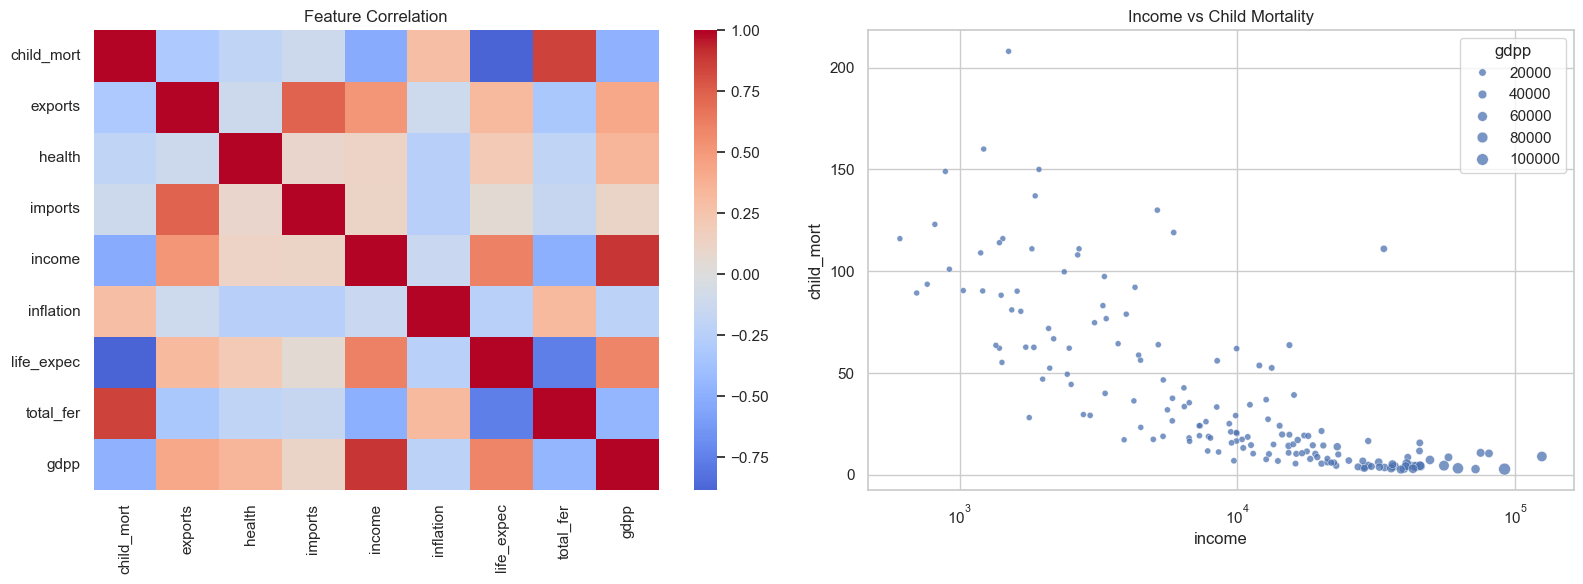

In [2]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:\n", df.isna().sum())
display(df.describe(include="all").T)

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Feature Correlation")
sns.scatterplot(data=df, x="income", y="child_mort", size="gdpp", alpha=.75, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Income vs Child Mortality")
plt.tight_layout()
plt.show()


## 3. Create a transparent classification target

The proxy **assistance priority** score combines six risk indicators after robust scaling:

- higher child mortality, fertility, and inflation increase priority;
- lower income, life expectancy, and GDP per capita increase priority.

The score is divided into three equally sized tiers. To reduce direct target leakage, supervised models use the remaining trade and health-spending features (`exports`, `health`, `imports`) to predict the tier.


In [3]:
risk_features = ["child_mort", "total_fer", "inflation", "income", "life_expec", "gdpp"]
risk_direction = np.array([1, 1, 1, -1, -1, -1])
risk_scaled = RobustScaler().fit_transform(df[risk_features])
df["priority_score"] = (risk_scaled * risk_direction).mean(axis=1)
df["priority_tier"] = pd.qcut(
    df["priority_score"], q=3, labels=["Low Priority", "Medium Priority", "High Priority"]
)

print(df["priority_tier"].value_counts())
display(df.sort_values("priority_score", ascending=False)[
    ["country", "priority_tier", "priority_score"] + risk_features
].head(10))


priority_tier
Low Priority       56
High Priority      56
Medium Priority    55
Name: count, dtype: int64


,country,priority_tier,priority_score,child_mort,total_fer,inflation,income,life_expec,gdpp
113,Nigeria,High Priority,2.709531,130.0,5.84,104.00,5150,60.5,2330
66,Haiti,High Priority,1.377789,208.0,3.33,5.45,1500,32.1,662
37,"Congo, Dem. Rep.",High Priority,1.279628,116.0,6.54,20.80,609,57.5,334
132,Sierra Leone,High Priority,1.271724,160.0,5.20,17.20,1220,55.0,399
3,Angola,High Priority,1.163458,119.0,6.16,22.40,5900,60.1,3530
32,Chad,High Priority,1.116006,150.0,6.59,6.39,1930,56.5,897
31,Central African Republic,High Priority,1.066219,149.0,5.21,2.01,888,47.5,446
63,Guinea,High Priority,1.058078,109.0,5.34,16.10,1190,58.0,648
26,Burundi,High Priority,1.026576,93.6,6.26,12.30,764,57.7,231
112,Niger,High Priority,1.016220,123.0,7.49,2.55,814,58.8,348


## 4. Supervised classification and ensemble comparison

In [4]:
classification_features = ["exports", "health", "imports"]
X = df[classification_features]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["priority_tier"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=500, min_samples_leaf=2, class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])
}

try:
    from xgboost import XGBClassifier
    models["XGBoost"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(
            n_estimators=300, max_depth=3, learning_rate=0.04,
            subsample=0.85, colsample_bytree=0.85,
            objective="multi:softprob", eval_metric="mlogloss",
            random_state=RANDOM_STATE
        ))
    ])
except ImportError:
    print("XGBoost is not installed; continuing with the available models.")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results, fitted_models = [], {}
for name, model in models.items():
    cv_f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    fitted_models[name] = model
    results.append({
        "model": name,
        "cv_f1_macro_mean": cv_f1.mean(),
        "cv_f1_macro_std": cv_f1.std(),
        "test_accuracy": accuracy_score(y_test, pred),
        "test_f1_macro": f1_score(y_test, pred, average="macro")
    })

model_results = pd.DataFrame(results).sort_values("test_f1_macro", ascending=False)
display(model_results.style.format(precision=3))


,model,cv_f1_macro_mean,cv_f1_macro_std,test_accuracy,test_f1_macro
1,Random Forest,0.491,0.101,0.524,0.533
0,Logistic Regression,0.519,0.029,0.524,0.520
2,XGBoost,nan,nan,0.476,0.489


## 5. Best-model evaluation

Best model: Random Forest
                 precision    recall  f1-score   support

  High Priority       0.53      0.57      0.55        14
   Low Priority       0.78      0.50      0.61        14
Medium Priority       0.39      0.50      0.44        14

       accuracy                           0.52        42
      macro avg       0.57      0.52      0.53        42
   weighted avg       0.57      0.52      0.53        42



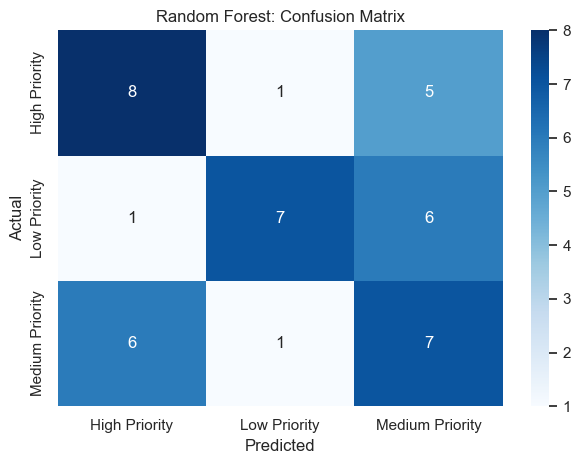

In [5]:
best_name = model_results.iloc[0]["model"]
best_model = fitted_models[best_name]
best_pred = best_model.predict(X_test)

print("Best model:", best_name)
print(classification_report(y_test, best_pred, target_names=label_encoder.classes_))
sns.heatmap(
    confusion_matrix(y_test, best_pred), annot=True, fmt="d", cmap="Blues",
    xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_
)
plt.title(f"{best_name}: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## 6. Random Forest feature importance

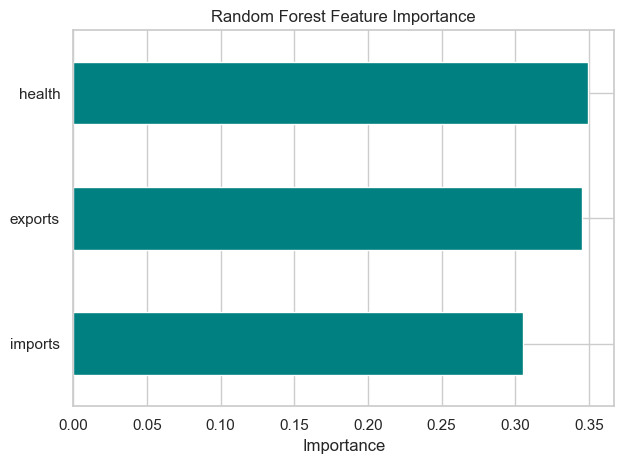

,importance
health,0.349620
exports,0.345332
imports,0.305048


In [6]:
rf = fitted_models["Random Forest"].named_steps["model"]
importance = pd.Series(rf.feature_importances_, index=classification_features).sort_values()
importance.plot(kind="barh", color="teal", title="Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
display(importance.sort_values(ascending=False).to_frame("importance"))


## 7. K-Means: choose the number of segments

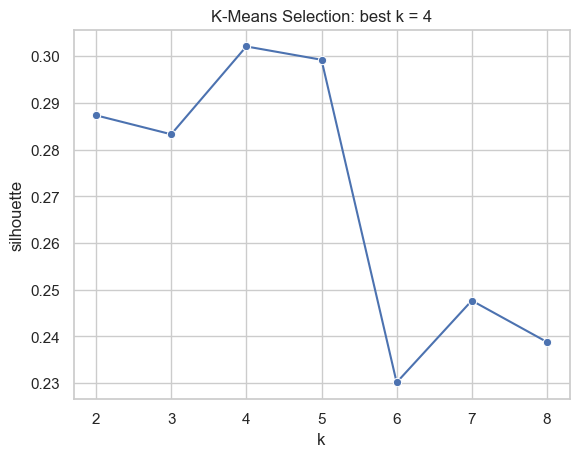

,k,silhouette
0,2,0.287357
1,3,0.283296
2,4,0.302108
3,5,0.299259
4,6,0.230149
5,7,0.247681
6,8,0.238811


In [7]:
cluster_features = numeric_cols
cluster_scaler = StandardScaler()
X_cluster = cluster_scaler.fit_transform(df[cluster_features])

k_scores = []
for k in range(2, 9):
    labels = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit_predict(X_cluster)
    k_scores.append({"k": k, "silhouette": silhouette_score(X_cluster, labels)})
k_scores = pd.DataFrame(k_scores)
best_k = int(k_scores.loc[k_scores["silhouette"].idxmax(), "k"])

sns.lineplot(data=k_scores, x="k", y="silhouette", marker="o")
plt.title(f"K-Means Selection: best k = {best_k}")
plt.show()

kmeans = KMeans(n_clusters=best_k, n_init=30, random_state=RANDOM_STATE)
df["kmeans_cluster"] = kmeans.fit_predict(X_cluster)
display(k_scores)


## 8. DBSCAN density segmentation and parameter search

In [8]:
dbscan_results = []
for eps in np.arange(0.8, 3.1, 0.2):
    for min_samples in [3, 4, 5, 6]:
        labels = DBSCAN(eps=float(eps), min_samples=min_samples).fit_predict(X_cluster)
        non_noise = labels != -1
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        score = np.nan
        if n_clusters >= 2 and non_noise.sum() > n_clusters:
            score = silhouette_score(X_cluster[non_noise], labels[non_noise])
        dbscan_results.append({
            "eps": round(float(eps), 1), "min_samples": min_samples,
            "clusters": n_clusters, "noise_points": int((labels == -1).sum()),
            "silhouette_non_noise": score
        })

dbscan_search = pd.DataFrame(dbscan_results)
valid_dbscan = dbscan_search.dropna(subset=["silhouette_non_noise"])
if len(valid_dbscan):
    chosen = valid_dbscan.sort_values(
        ["silhouette_non_noise", "noise_points"], ascending=[False, True]
    ).iloc[0]
    dbscan = DBSCAN(eps=chosen["eps"], min_samples=int(chosen["min_samples"]))
    df["dbscan_cluster"] = dbscan.fit_predict(X_cluster)
    print("Selected DBSCAN parameters:", chosen.to_dict())
else:
    df["dbscan_cluster"] = DBSCAN(eps=1.5, min_samples=5).fit_predict(X_cluster)
    print("No multi-cluster DBSCAN solution found; using fallback parameters.")

display(df["dbscan_cluster"].value_counts().sort_index().to_frame("countries"))


Selected DBSCAN parameters: {'eps': 1.0, 'min_samples': 6.0, 'clusters': 2.0, 'noise_points': 113.0, 'silhouette_non_noise': 0.44427637851303103}


,countries
dbscan_cluster,
-1,113
0,42
1,12


## 9. Visualize and profile customer/country segments

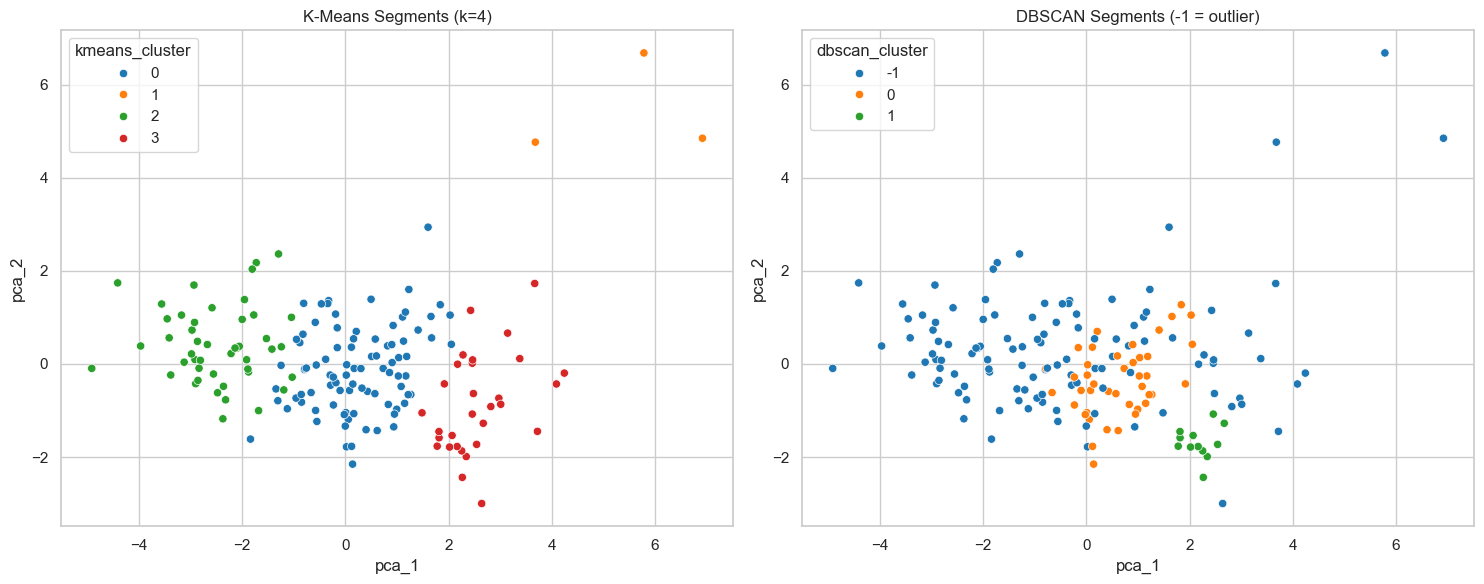

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,country_count
kmeans_cluster,,,,,,,,,,
0,21.74,41.32,6.26,48.08,12972.39,7.43,72.76,2.29,6912.64,88
1,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67,3
2,93.84,28.84,6.35,42.13,3738.98,12.09,59.23,5.05,1826.13,46
3,4.95,45.83,9.17,39.74,45250.00,2.74,80.38,1.80,43333.33,30


In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_cluster)
df["pca_1"], df["pca_2"] = coords[:, 0], coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=df, x="pca_1", y="pca_2", hue="kmeans_cluster", palette="tab10", ax=axes[0])
axes[0].set_title(f"K-Means Segments (k={best_k})")
sns.scatterplot(data=df, x="pca_1", y="pca_2", hue="dbscan_cluster", palette="tab10", ax=axes[1])
axes[1].set_title("DBSCAN Segments (-1 = outlier)")
plt.tight_layout()
plt.show()

cluster_profile = df.groupby("kmeans_cluster")[cluster_features].mean().round(2)
cluster_sizes = df["kmeans_cluster"].value_counts().sort_index().rename("country_count")
display(cluster_profile.join(cluster_sizes))


## 10. Actionable segment naming and recommendations

In [10]:
profile = df.groupby("kmeans_cluster")[["priority_score", "income", "gdpp", "child_mort", "life_expec"]].mean()
ranked = profile["priority_score"].sort_values(ascending=False).index.tolist()
segment_names = {}
if len(ranked) == 2:
    names = ["High-Need / Immediate Support", "Stable / Growth Opportunity"]
else:
    names = ["High-Need / Immediate Support"] + ["Developing / Targeted Support"] * (len(ranked) - 2) + ["Prosperous / Partnership Opportunity"]
for cluster, name in zip(ranked, names):
    segment_names[cluster] = name

df["segment_name"] = df["kmeans_cluster"].map(segment_names)
recommendations = {
    "High-Need / Immediate Support": "Prioritize health, child-survival, income, and infrastructure programs.",
    "Developing / Targeted Support": "Use targeted investment, trade enablement, and preventive-health initiatives.",
    "Prosperous / Partnership Opportunity": "Focus on strategic partnerships, innovation, and knowledge transfer.",
    "Stable / Growth Opportunity": "Focus on sustainable growth partnerships and targeted development support."
}
df["recommended_action"] = df["segment_name"].map(recommendations)
df["predicted_priority_tier"] = label_encoder.inverse_transform(best_model.predict(df[classification_features]))

final_columns = [
    "country", "priority_tier", "predicted_priority_tier", "priority_score",
    "kmeans_cluster", "segment_name", "dbscan_cluster", "recommended_action"
]
intelligence_table = df[final_columns].sort_values("priority_score", ascending=False)
display(intelligence_table.head(20))


,country,priority_tier,predicted_priority_tier,priority_score,kmeans_cluster,segment_name,dbscan_cluster,recommended_action
113,Nigeria,High Priority,Medium Priority,2.709531,2,High-Need / Immediate Support,-1,"Prioritize health, child-survival, income, and..."
66,Haiti,High Priority,High Priority,1.377789,2,High-Need / Immediate Support,-1,"Prioritize health, child-survival, income, and..."
37,"Congo, Dem. Rep.",High Priority,Medium Priority,1.279628,2,High-Need / Immediate Support,-1,"Prioritize health, child-survival, income, and..."
132,Sierra Leone,High Priority,High Priority,1.271724,2,High-Need / Immediate Support,-1,"Prioritize health, child-survival, income, and..."
3,Angola,High Priority,High Priority,1.163458,2,High-Need / Immediate Support,-1,"Prioritize health, child-survival, income, and..."
32,Chad,High Priority,High Priority,1.116006,2,High-Need / Immediate Support,-1,"Prioritize health, child-survival, income, and..."
31,Central African Republic,High Priority,Medium Priority,1.066219,2,High-Need / Immediate Support,-1,"Prioritize health, child-survival, income, and..."
63,Guinea,High Priority,High Priority,1.058078,2,High-Need / Immediate Support,-1,"Prioritize health, child-survival, income, and..."
26,Burundi,High Priority,High Priority,1.026576,2,High-Need / Immediate Support,-1,"Prioritize health, child-survival, income, and..."
112,Niger,High Priority,High Priority,1.016220,2,High-Need / Immediate Support,-1,"Prioritize health, child-survival, income, and..."


## 11. Export intelligence outputs

In [11]:
intelligence_table.to_csv("country_intelligence_results.csv", index=False)
model_results.to_csv("classification_model_comparison.csv", index=False)
cluster_profile.to_csv("kmeans_cluster_profiles.csv")
dbscan_search.to_csv("dbscan_parameter_search.csv", index=False)

print("Saved:")
for path in [
    "country_intelligence_results.csv", "classification_model_comparison.csv",
    "kmeans_cluster_profiles.csv", "dbscan_parameter_search.csv"
]:
    print(" -", path)


Saved:
 - country_intelligence_results.csv
 - classification_model_comparison.csv
 - kmeans_cluster_profiles.csv
 - dbscan_parameter_search.csv


## Executive summary

- The classification layer predicts a transparent **assistance-priority proxy**, comparing a baseline with Random Forest and XGBoost ensembles.
- K-Means creates mutually exclusive strategic segments; the number of segments is selected using silhouette score.
- DBSCAN identifies dense groups and unusual countries (`-1`), which are valuable for case-by-case review.
- The exported intelligence table combines predictions, segments, outlier flags, and recommended actions.

For production use, replace the proxy target with validated business or policy outcomes, add temporal data, monitor drift and fairness, and involve domain experts before acting on recommendations.
